In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np

db = mysql.connector.connect(
    host = "localhost",
    username = "root",
    password = "12345",
    database = "ecommerce")

cur = db.cursor()

# list all unique cities where customers are located 

In [25]:
query = """SELECT DISTINCT customer_city FROM customers"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data)
df.head()

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


# count the numbers of oreder placed in 2017

In [3]:
query = """select count(order_id) from orders where year(order_purchase_timestamp)=2017"""

cur.execute(query)

data = cur.fetchall()

"total order are placed in 2017 are",data[0][0]

('total order are placed in 2017 are', 90202)

# Find the total sales per category.

In [12]:
query = """ select upper(products.product_category) category,
round(sum(payments.payment_value),2) sales
from products join order_items
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by category
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data,columns = ["category","sales"])
df

,category,sales
0,PERFUMERY,506738.66
1,FURNITURE DECORATION,1430176.39
2,TELEPHONY,486882.05
3,BED TABLE BATH,1712553.67
4,AUTOMOTIVE,852294.33
...,...,...
69,CDS MUSIC DVDS,1199.43
70,LA CUISINE,2913.53
71,FASHION CHILDREN'S CLOTHING,785.67
72,PC GAMER,2174.43


# calculate the percentage of orders that were paid in installments

In [18]:
query = """ select (sum(case when payment_installments >= 1 then 1
else 0 end))/count(*)*100 from payments
"""

cur.execute(query)

data = cur.fetchall()

"the percentage of orders that were paid in installments is ",data[0][0]


('the percentage of orders that were paid in installments is ',
 Decimal('99.9981'))

# Count the number of customers from each state.

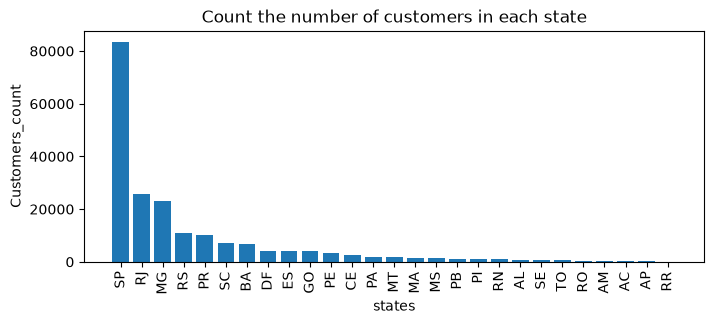

In [15]:
query = """ select customer_state, count(customer_id)
from customers group by customer_state
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["state","customer_count"])
df = df.sort_values(by = "customer_count", ascending = False)

plt.figure(figsize = (8,3))
plt.bar(df["state"],df["customer_count"])
plt.xticks(rotation = 90)
plt.xlabel ("states")
plt.ylabel ("Customers_count")
plt.title ("Count the number of customers in each state")
plt.show()

# Calculate the numbers of orders per month in 2018

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_28304\1142949203.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = df["months"],y = df["order_count"], data = df, order = o, palette = "viridis")


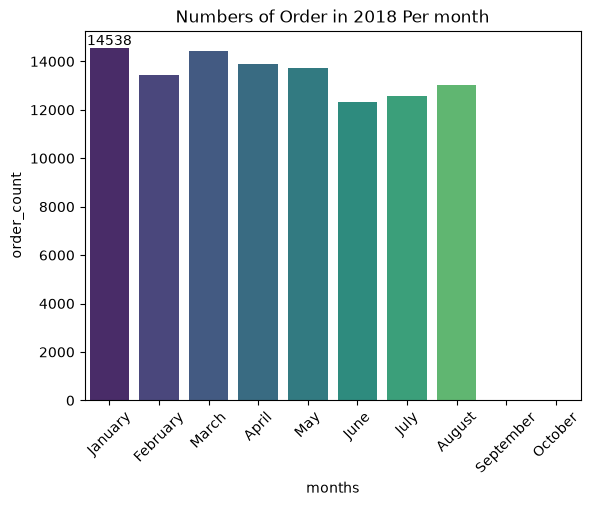

In [16]:
query = """ select MONTHNAME(order_purchase_timestamp) months, COUNT(order_id) order_count
from orders where year(order_purchase_timestamp) = 2018
group by months
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns = ["months","order_count"])
o = ["January","February","March","April","May","June","July","August","September","October"]

plt.xticks(rotation = 45)
ax = sns.barplot(x = df["months"],y = df["order_count"], data = df, order = o, palette = "viridis")

ax.bar_label(ax.containers[0])
plt.title ("Numbers of Order in 2018 Per month")
plt.show()

#  Find the average number of products per order, grouped by customer city.

In [14]:
query = """ with count_per_order as
(select orders.order_id, orders.customer_id,count(order_items.order_id ) as oc
from orders join order_items
on orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id)

select customers.customer_city , round (avg(count_per_order.oc),2) average_orders
from customers join count_per_order
on customers.customer_id = count_per_order.customer_id
group by customers.customer_city order by average_orders
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Average_city", "Average Orders"])
df.head(10)

,Average_city,Average Orders
0,serranopolis,2.00
1,fortim,2.00
2,cairu,2.00
3,epitaciolandia,2.00
4,urucania,2.00
5,porto calvo,2.00
6,ipupiara,2.00
7,americo de campos,2.00
8,sao joao do sobrado,2.00
9,bora,2.00


# Calculate the percentage of total revenue contributed by each product category.

In [9]:
query = """ select upper(products.product_category) category,
round((sum(payments.payment_value)/(select sum(payment_value)from payments))*100,2) sales_percentage
from products join order_items
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by category order by sales_percentage desc;
"""

cur.execute(query)

data = cur.fetchall()

df= pd.DataFrame(data,columns = ["Category", "Percentage Distribution"])

df


,Category,Percentage Distribution
0,BED TABLE BATH,42.79
1,HEALTH BEAUTY,41.41
2,COMPUTER ACCESSORIES,39.61
3,FURNITURE DECORATION,35.73
4,WATCHES PRESENT,35.71
...,...,...
69,PC GAMER,0.05
70,HOUSE COMFORT 2,0.04
71,CDS MUSIC DVDS,0.03
72,FASHION CHILDREN'S CLOTHING,0.02


# Identify the correlation between product price and the number of times a product has been purchased.

In [6]:
query = """select products.product_category,
count(order_items.product_id),
round(avg(order_items.price),2)
from products join order_items
on products.product_id = order_items.product_id
group by products.product_category
"""

cur.execute(query)

data = cur.fetchall()

df= pd.DataFrame(data,columns = ["Category", "Order_count","Price"])

arr1 = df["Order_count"]
arr2 = df["Price"]

a = np.corrcoef([arr1, arr2])
print("the correlation between price and number of items a product has purchased is ",a[0][1])

the correlation between price and number of items a product has purchased is  -0.10631514167157562


# Calculate the total revenue generated by each seller, and rank them by revenue.

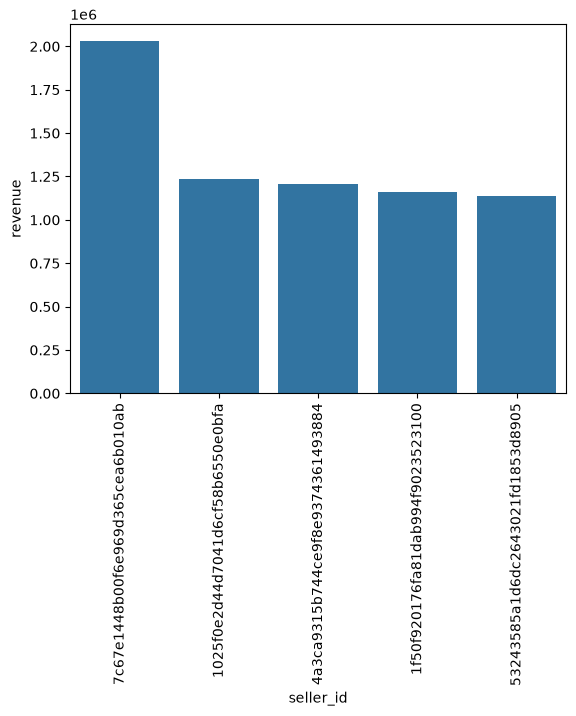

In [13]:
query = """ select *, dense_rank() over(order by revenue desc) as rn from
(select order_items.seller_id, sum(payments.payment_value)
revenue from order_items join payments
on order_items.order_id = payments.order_id
group by order_items.seller_id) as a
"""

cur.execute(query)

data = cur.fetchall()
df = pd. DataFrame(data, columns = ["seller_id","revenue","rank"])
df = df.head()
sns.barplot(x= "seller_id",y = "revenue", data = df)
plt.xticks(rotation = 90)
plt.show()

# Calculate the moving average of order values for each customer over their order history.

In [15]:
query = """select customer_id, order_purchase_timestamp,payment_value,
avg(payment_value) over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from 
(select orders.customer_id, orders.order_purchase_timestamp,
payments.payment_value
from payments join orders
on payments.order_id = orders.order_id) as t
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data)
df

,0,1,2,3
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
2,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
3,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
4,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
...,...,...,...,...
415539,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000
415540,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
415541,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
415542,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001


# Calculate the cumulative sales per month for each year.

In [16]:
query = """ select years, months, sum(payment)
over(order by years, months) as cumulative_sales from 
(select year(orders.order_purchase_timestamp) as years,
monthname(orders.order_purchase_timestamp) as months,
round(sum(payments.payment_value),2) as payment from orders join payments
on orders.order_id = payments.order_id
group by years, months order by years, months) as sales
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data)
df

,0,1,2
0,2016,December,78.48
1,2016,October,236440.40
2,2016,September,237449.36
3,2017,April,1908601.48
4,2017,August,4606186.76
5,2017,December,8119792.68
6,2017,February,9287424.72
7,2017,January,9841376.88
8,2017,July,12210908.56
9,2017,June,14256014.08


# Calculate the year-over-year growth rate of total sales.

In [29]:
query = """with a as (select year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value),2) as payment from orders join payments
on orders.order_id = payments.order_id
group by years order by years)

select years, (payment - lag(payment, 1) over(order by years)) /
lag(payment, 1) over(order by years) * 100
from a
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years","yoy% growth"])
df

,years,yoy% growth
0,2016,NaN
1,2017,12112.703757
2,2018,20.000924


# Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase

In [30]:
query = """with a as (select customers.customer_id,
min(orders.order_purchase_timestamp) first_order
from customers join orders
on customers.customer_id = orders.customer_id
group by customers.customer_id),

b as( select a.customer_id, count(distinct orders.order_purchase_timestamp) next_order
from a join orders
on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp > first_order
and orders.order_purchase_timestamp < 
date_add(first_order, interval 6 month)
group by a.customer_id)

select 100 * (count(distinct a.customer_id)/ count(distinct b.customer_id))
from a left join b
on a.customer_id = b.customer_id 
"""

cur.execute(query)

data = cur.fetchall()
data

[(None,)]

# Identify the top 3 customers who spent the most money in each year.

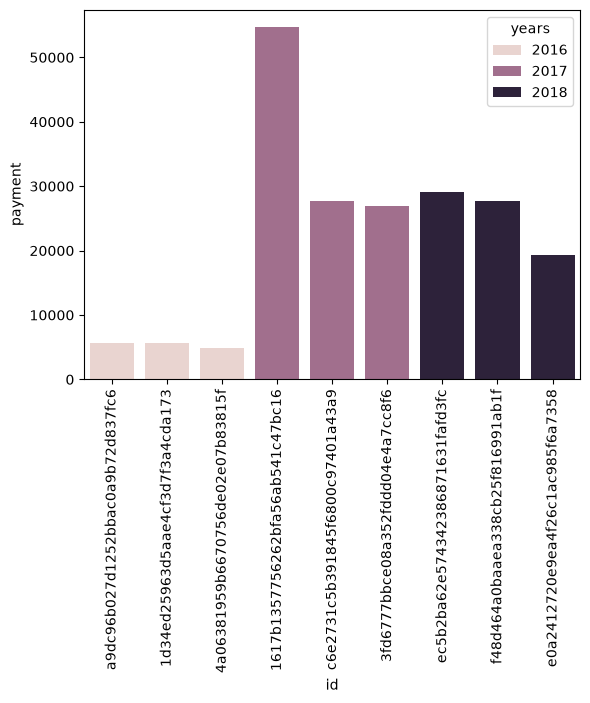

In [37]:
query = """select years, customer_id, payment, d_rank
from 
(select year(orders.order_purchase_timestamp) as years,
orders.customer_id,
sum(payments.payment_value) payment,
dense_rank() over (partition by year (orders.order_purchase_timestamp)
order by sum(payments.payment_value)desc) d_rank
from orders join payments
on payments.order_id = orders.order_id
group by year(orders.order_purchase_timestamp),
orders.customer_id) as a
where d_rank <= 3
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years", "id", "payment", "rank"])
sns.barplot(x = "id", y= "payment", data= df, hue = "years")
plt.xticks(rotation = 90)
plt.show()